# Random Forest Model for Heat Risk Prediction

This notebook implements Random Forest models for both regression (forecast apparent temperature) and classification (predict heat risk) tasks.

## Tasks:
1. ✅ Load train/validation/test splits
2. ✅ Feature preparation and selection
3. ✅ Handle categorical variables
4. ✅ Build Random Forest regressor (forecast `heat_index_next_day` - apparent temperature)
5. ✅ Build Random Forest classifier (predict `heat_risk` - binary classification based on temperature conditions)
6. ✅ Hyperparameter tuning (optional)
7. ✅ Evaluate models
8. ✅ Feature importance analysis
9. ✅ Save models and predictions

**Note**: Heat risk is typically derived from apparent temperature thresholds (e.g., >90°F = high risk). The regression task forecasts the continuous temperature value, while the classification task predicts the binary risk category.


## Step 1: Mount Google Drive and Import Libraries


In [1]:
# Mount Google Drive and set repo path (Colab)
import os
from pathlib import Path

repo_path = '/content/drive/MyDrive/SHADE-ML-Team'
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    if not os.path.exists(repo_path):
        os.makedirs('/content/drive/MyDrive', exist_ok=True)
    os.chdir(repo_path)
    print(f"Using repo at: {os.getcwd()}")
except ImportError:
    # Running locally - set directory to project root
    current_dir = Path(os.getcwd())
    if current_dir.name == 'notebooks':
        project_root = current_dir.parent
    else:
        project_root = current_dir
        while project_root != project_root.parent:
            if (project_root / '.git').exists() or (project_root / 'README.md').exists():
                break
            project_root = project_root.parent
    
    os.chdir(project_root)
    print(f"Running locally; set CWD to project root: {os.getcwd()}")


Running locally; set CWD to project root: c:\Users\hrudi\OneDrive\Documents\TAMU\SHADE\ML-Repo


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

# Set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")


Libraries imported successfully!


## Step 2: Load Data Splits


In [3]:
# Load train/validation/test splits
train_data = pd.read_csv('data/processed/train_data.csv')
val_data = pd.read_csv('data/processed/validation_data.csv')
test_data = pd.read_csv('data/processed/test_data.csv')

print("✓ Data loaded successfully!")
print(f"Train shape: {train_data.shape}")
print(f"Validation shape: {val_data.shape}")
print(f"Test shape: {test_data.shape}")
print(f"\nColumns: {train_data.columns.tolist()}")


✓ Data loaded successfully!
Train shape: (7248, 32)
Validation shape: (1553, 32)
Test shape: (1553, 32)

Columns: ['Date', 'TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF', 'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles', 'PrecipitationSumInches', 'Events', 'Year', 'Month', 'Day', 'DayOfYear', 'Season', 'DailyTempRange', 'TempCategory', 'HumidityCategory', 'TempAvgF_squared', 'HumidityAvgPercent_squared', 'Pressure_squared', 'TempPressure', 'PrevDayTemp', 'PrevDayHumidity', 'TempAvg_7day', 'HumidityAvg_7day', 'HeatIndex', 'heat_index_high', 'temp_percentile_high', 'heat_risk_day', 'heat_risk', 'heat_index_next_day']


## Step 3: Feature Preparation and Selection

Prepare features for Random Forest models. Select which features to include for both regression (forecast apparent temperature) and classification (predict heat risk) tasks.


In [4]:
# SELECT FEATURES FOR RANDOM FOREST
# Review which features are relevant for forecasting apparent temperature and predicting heat risk
# Consider temperature, humidity, pressure, time-based features, etc.

print("=" * 80)
print("FEATURE PREPARATION AND SELECTION")
print("=" * 80)

# Select features (similar to XGBoost approach)
feature_cols = [
    # Temperature features
    'TempHighF', 'TempLowF', 'TempAvgF',
    # Humidity and dew point
    'HumidityAvgPercent', 'DewPointAvgF',
    # Weather features
    'HeatIndex', 'sealevelpressure', 'VisibilityAvgMiles',
    # Time-based features
    'Year', 'Month', 'Day', 'DayOfYear',
    # Derived features
    'DailyTempRange', 'TempAvg_7day', 'HumidityAvg_7day', 'PrevDayTemp', 'PrevDayHumidity',
    # Interaction and polynomial features
    'TempAvgF_squared', 'HumidityAvgPercent_squared', 'Pressure_squared', 'TempPressure'
]

# Check which features exist
available_features = [col for col in feature_cols if col in train_data.columns]
missing_features = [col for col in feature_cols if col not in train_data.columns]

if missing_features:
    print(f"⚠ WARNING: Missing features: {missing_features}")
    feature_cols = available_features

print(f"\n✓ Selected {len(feature_cols)} features")
print(f"Features: {feature_cols}")

# Check for missing values in selected features
print(f"\nMissing values in features:")
print(f"  Train: {train_data[feature_cols].isnull().sum().sum()} total")
print(f"  Val: {val_data[feature_cols].isnull().sum().sum()} total")
print(f"  Test: {test_data[feature_cols].isnull().sum().sum()} total")


FEATURE PREPARATION AND SELECTION

✓ Selected 21 features
Features: ['TempHighF', 'TempLowF', 'TempAvgF', 'HumidityAvgPercent', 'DewPointAvgF', 'HeatIndex', 'sealevelpressure', 'VisibilityAvgMiles', 'Year', 'Month', 'Day', 'DayOfYear', 'DailyTempRange', 'TempAvg_7day', 'HumidityAvg_7day', 'PrevDayTemp', 'PrevDayHumidity', 'TempAvgF_squared', 'HumidityAvgPercent_squared', 'Pressure_squared', 'TempPressure']

Missing values in features:
  Train: 2 total
  Val: 0 total
  Test: 0 total


## Step 4: Handle Categorical Variables

Handle categorical variables for Random Forest. Identify and encode categorical columns.


In [5]:
# HANDLE CATEGORICAL VARIABLES
# Identify categorical variables and encode them appropriately

# Identify categorical columns (e.g., 'Season', 'Events')
categorical_cols = ['Season']  # Add other categorical columns as needed
existing_categorical = [col for col in categorical_cols if col in train_data.columns]

if existing_categorical:
    print(f"\nEncoding categorical variables: {existing_categorical}")
    label_encoders = {}
    
    # Option 1: Label Encoding (Random Forest can handle integer-encoded categories)
    for col in existing_categorical:
        le = LabelEncoder()
        train_data[f'{col}_encoded'] = le.fit_transform(train_data[col].astype(str))
        val_data[f'{col}_encoded'] = le.transform(val_data[col].astype(str))
        test_data[f'{col}_encoded'] = le.transform(test_data[col].astype(str))
        label_encoders[col] = le
    
    # Update feature columns list to include encoded features
    feature_cols.extend([f'{col}_encoded' for col in existing_categorical])
    feature_cols = [col for col in feature_cols if col not in categorical_cols]
    print(f"✓ Categorical variables encoded")
else:
    print("\nNo categorical variables to encode")



Encoding categorical variables: ['Season']
✓ Categorical variables encoded


## Step 5: Prepare Features and Targets

Separate features and targets for regression and classification. Create feature matrices (X) and target vectors (y) for both tasks.


In [6]:
# PREPARE FEATURES AND TARGETS
# Separate features (X) and targets (y) for both regression and classification tasks

# Prepare feature matrices
X_train = train_data[feature_cols].copy()
X_val = val_data[feature_cols].copy()
X_test = test_data[feature_cols].copy()

# Prepare regression targets
# Regression target: heat_index_next_day (apparent temperature - continuous value)
y_train_reg = train_data['heat_index_next_day'].copy()
y_val_reg = val_data['heat_index_next_day'].copy()
y_test_reg = test_data['heat_index_next_day'].copy()

# Prepare classification targets
# Classification target: heat_risk (binary classification: 0=low risk, 1=high risk)
y_train_cls = train_data['heat_risk'].copy()
y_val_cls = val_data['heat_risk'].copy()
y_test_cls = test_data['heat_risk'].copy()

# Handle missing values in targets
# Remove rows with NaN in regression target
train_mask = ~y_train_reg.isnull()
val_mask = ~y_val_reg.isnull()
test_mask = ~y_test_reg.isnull()

# Apply masks to X and y
X_train = X_train[train_mask].copy()
y_train_reg = y_train_reg[train_mask].copy()
y_train_cls = y_train_cls[train_mask].copy()

X_val = X_val[val_mask].copy()
y_val_reg = y_val_reg[val_mask].copy()
y_val_cls = y_val_cls[val_mask].copy()

X_test = X_test[test_mask].copy()
y_test_reg = y_test_reg[test_mask].copy()
y_test_cls = y_test_cls[test_mask].copy()

# Print summary statistics
print(f"\nFinal feature shape: {X_train.shape}")
print(f"Regression target - Mean: {y_train_reg.mean():.2f}°F, Std: {y_train_reg.std():.2f}°F")
print(f"Classification target distribution:\n{y_train_cls.value_counts()}")
print(f"Classification target - Class 1: {(y_train_cls == 1).mean()*100:.2f}%")



Final feature shape: (7248, 22)
Regression target - Mean: 69.37°F, Std: 16.61°F
Classification target distribution:
heat_risk
0    7003
1     245
Name: count, dtype: int64
Classification target - Class 1: 3.38%


## Step 6: Build Random Forest Regressor

Build and train Random Forest regressor. Initialize, train, predict, and evaluate. **Target**: Forecast `heat_index_next_day` (apparent temperature - continuous value prediction).


In [7]:
# BUILD RANDOM FOREST REGRESSOR
# Implement Random Forest regressor: initialize, train, predict, and evaluate
# Target: Forecast heat_index_next_day (apparent temperature - continuous value)

print("=" * 80)
print("BUILDING RANDOM FOREST REGRESSOR")
print("=" * 80)

# Set Random Forest hyperparameters
# Research appropriate values for regression tasks
rf_n_estimators = 200  # Number of trees
rf_max_depth = 15      # Maximum depth (None for unlimited)
rf_min_samples_split = 5   # Minimum samples to split
rf_min_samples_leaf = 2    # Minimum samples in leaf
rf_max_features = 'sqrt'    # Features to consider ('sqrt', 'log2', or number)

# Initialize Random Forest regressor
rf_regressor = RandomForestRegressor(
    n_estimators=rf_n_estimators,
    max_depth=rf_max_depth,
    min_samples_split=rf_min_samples_split,
    min_samples_leaf=rf_min_samples_leaf,
    max_features=rf_max_features,
    random_state=42,
    n_jobs=-1
)

# Train the model
print("\nTraining Random Forest regressor...")
rf_regressor.fit(X_train, y_train_reg)
print("✓ Training complete")

# Make predictions
y_train_pred_reg = rf_regressor.predict(X_train)
y_val_pred_reg = rf_regressor.predict(X_val)
y_test_pred_reg = rf_regressor.predict(X_test)

# Evaluate model performance
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_reg))
val_rmse = np.sqrt(mean_squared_error(y_val_reg, y_val_pred_reg))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_reg))
train_mae = mean_absolute_error(y_train_reg, y_train_pred_reg)
val_mae = mean_absolute_error(y_val_reg, y_val_pred_reg)
test_mae = mean_absolute_error(y_test_reg, y_test_pred_reg)
train_r2 = r2_score(y_train_reg, y_train_pred_reg)
val_r2 = r2_score(y_val_reg, y_val_pred_reg)
test_r2 = r2_score(y_test_reg, y_test_pred_reg)

# Print evaluation results
print("\n" + "=" * 80)
print("RANDOM FOREST REGRESSION PERFORMANCE")
print("=" * 80)
print(f"Train - RMSE: {train_rmse:.2f}°F, MAE: {train_mae:.2f}°F, R²: {train_r2:.4f}")
print(f"Val   - RMSE: {val_rmse:.2f}°F, MAE: {val_mae:.2f}°F, R²: {val_r2:.4f}")
print(f"Test  - RMSE: {test_rmse:.2f}°F, MAE: {test_mae:.2f}°F, R²: {test_r2:.4f}")


BUILDING RANDOM FOREST REGRESSOR

Training Random Forest regressor...
✓ Training complete

RANDOM FOREST REGRESSION PERFORMANCE
Train - RMSE: 2.88°F, MAE: 2.04°F, R²: 0.9700
Val   - RMSE: 5.35°F, MAE: 3.93°F, R²: 0.9002
Test  - RMSE: 5.69°F, MAE: 4.16°F, R²: 0.8954


In [8]:
# BUILD RANDOM FOREST CLASSIFIER
# Implement Random Forest classifier: check class balance, initialize, train, predict, and evaluate
# Target: Predict heat_risk (binary classification based on temperature conditions)

print("=" * 80)
print("BUILDING RANDOM FOREST CLASSIFIER")
print("=" * 80)

# Check class balance
class_counts_train = y_train_cls.value_counts()
class_proportions_train = y_train_cls.value_counts(normalize=True)

print(f"\nClass Distribution - Training set:")
print(class_counts_train)
print(class_proportions_train)

# Determine if classes are imbalanced
is_imbalanced = (class_proportions_train.min() < 0.1) if len(class_proportions_train) == 2 else False
if is_imbalanced:
    print("\n⚠ Classes are imbalanced - using class_weight='balanced'")
    rf_cls_class_weight = 'balanced'
else:
    rf_cls_class_weight = None

# Set Random Forest classifier hyperparameters
# Reuse or adjust hyperparameters from regressor
rf_cls_n_estimators = 200  # Number of trees
rf_cls_max_depth = 15      # Maximum depth
rf_cls_min_samples_split = 5   # Minimum samples to split
rf_cls_min_samples_leaf = 2    # Minimum samples in leaf
rf_cls_max_features = 'sqrt'   # Features to consider

# Initialize Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=rf_cls_n_estimators,
    max_depth=rf_cls_max_depth,
    min_samples_split=rf_cls_min_samples_split,
    min_samples_leaf=rf_cls_min_samples_leaf,
    max_features=rf_cls_max_features,
    class_weight=rf_cls_class_weight,
    random_state=42,
    n_jobs=-1
)

# Train the classifier
print("\nTraining Random Forest classifier...")
rf_classifier.fit(X_train, y_train_cls)
print("✓ Training complete")

# Make predictions
y_train_pred_cls = rf_classifier.predict(X_train)
y_val_pred_cls = rf_classifier.predict(X_val)
y_test_pred_cls = rf_classifier.predict(X_test)

# Evaluate classification performance
train_acc = accuracy_score(y_train_cls, y_train_pred_cls)
val_acc = accuracy_score(y_val_cls, y_val_pred_cls)
test_acc = accuracy_score(y_test_cls, y_test_pred_cls)
train_precision = precision_score(y_train_cls, y_train_pred_cls, zero_division=0)
val_precision = precision_score(y_val_cls, y_val_pred_cls, zero_division=0)
test_precision = precision_score(y_test_cls, y_test_pred_cls, zero_division=0)
train_recall = recall_score(y_train_cls, y_train_pred_cls, zero_division=0)
val_recall = recall_score(y_val_cls, y_val_pred_cls, zero_division=0)
test_recall = recall_score(y_test_cls, y_test_pred_cls, zero_division=0)
train_f1 = f1_score(y_train_cls, y_train_pred_cls, zero_division=0)
val_f1 = f1_score(y_val_cls, y_val_pred_cls, zero_division=0)
test_f1 = f1_score(y_test_cls, y_test_pred_cls, zero_division=0)

# Print evaluation results
print("\n" + "=" * 80)
print("RANDOM FOREST CLASSIFICATION PERFORMANCE")
print("=" * 80)
print(f"Train - Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
print(f"Val   - Accuracy: {val_acc:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
print(f"Test  - Accuracy: {test_acc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1: {test_f1:.4f}")


BUILDING RANDOM FOREST CLASSIFIER

Class Distribution - Training set:
heat_risk
0    7003
1     245
Name: count, dtype: int64
heat_risk
0    0.966198
1    0.033802
Name: proportion, dtype: float64

⚠ Classes are imbalanced - using class_weight='balanced'

Training Random Forest classifier...
✓ Training complete

RANDOM FOREST CLASSIFICATION PERFORMANCE
Train - Accuracy: 0.9979, Precision: 0.9423, Recall: 1.0000, F1: 0.9703
Val   - Accuracy: 0.9852, Precision: 0.8000, Recall: 0.8615, F1: 0.8296
Test  - Accuracy: 0.9865, Precision: 0.9306, Recall: 0.9241, F1: 0.9273


In [13]:
# DECIDE WHETHER TO PERFORM HYPERPARAMETER TUNING
# Set to True if you want to tune hyperparameters (takes longer)
#
# WHY TUNE FOR RANDOM FOREST?
# ============================
# YES - TUNING IS RECOMMENDED for this model, especially for REGRESSION:
#
# 1. REGRESSION OVERFITTING DETECTED:
#    - Train RMSE: 2.88°F vs Val RMSE: 5.35°F (ratio: 0.538)
#    - This is WORSE than XGBoost (ratio: 0.717)
#    - Large gap indicates model is memorizing training data
#    - Tuning can reduce overfitting by adjusting:
#      * max_depth (currently 15 - might be too high)
#      * min_samples_split (currently 5 - might need increase)
#      * min_samples_leaf (currently 2 - might need increase)
#
# 2. CLASSIFICATION OVERFITTING:
#    - Train Accuracy: 0.9979 vs Val Accuracy: 0.9852
#    - Train Recall: 1.0000 (perfect) vs Val Recall: 0.8615
#    - Perfect training recall suggests overfitting
#    - Tuning can improve generalization
#
# 3. RANDOM FOREST IS FASTER TO TUNE:
#    - Random Forest tuning is typically faster than XGBoost
#    - The parameter grid is smaller and simpler
#    - Worth the time investment given the overfitting issues
#
# 4. POTENTIAL BENEFITS:
#    - Reduce train/val gap (better generalization)
#    - Improve validation/test performance
#    - Find more efficient models (fewer trees, faster inference)
#    - Better balance between bias and variance
#
# RECOMMENDATION:
# - Set perform_tuning = True (especially for regression)
# - Consider using RandomizedSearchCV for faster exploration
# - Focus on regularization parameters (max_depth, min_samples_*)
#
perform_tuning = True  # Set to True to enable hyperparameter tuning

if perform_tuning:
    print("=" * 80)
    print("HYPERPARAMETER TUNING")
    print("=" * 80)
    
    # ADJUST PARAMETER GRIDS
    # Consider computational cost - start with smaller grids
    
    # Define parameter grid for Random Forest regression
    param_grid_reg = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
    # Perform GridSearchCV for regression
    print("\nTuning Random Forest Regressor...")
    grid_search_reg = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid=param_grid_reg,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    grid_search_reg.fit(X_train, y_train_reg)
    print(f"Best parameters: {grid_search_reg.best_params_}")
    rf_regressor = grid_search_reg.best_estimator_
    
    # Define parameter grid for Random Forest classification
    param_grid_cls = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [2, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': [None, 'balanced']
    }
    
    # Perform GridSearchCV for classification
    print("\nTuning Random Forest Classifier...")
    grid_search_cls = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid=param_grid_cls,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    grid_search_cls.fit(X_train, y_train_cls)
    print(f"Best parameters: {grid_search_cls.best_params_}")
    rf_classifier = grid_search_cls.best_estimator_
    
    print("\n✓ Hyperparameter tuning complete!")
    print("Note: Re-run prediction and evaluation cells after tuning")
else:
    print("=" * 80)
    print("SKIPPING HYPERPARAMETER TUNING")
    print("=" * 80)
    print("Set perform_tuning = True to enable hyperparameter tuning")
    print("Using initial models with default hyperparameters")


HYPERPARAMETER TUNING

Tuning Random Forest Regressor...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Tuning Random Forest Classifier...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters: {'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

✓ Hyperparameter tuning complete!
Note: Re-run prediction and evaluation cells after tuning


## Step 9: Evaluate and Compare Models

Comprehensive evaluation of both regression and classification models. Calculate metrics, create visualizations, and compare performance.


COMPREHENSIVE MODEL EVALUATION

REGRESSION PERFORMANCE (Forecasting Apparent Temperature)
Train - RMSE: 2.88°F, MAE: 2.04°F, R²: 0.9700
Val   - RMSE: 5.35°F, MAE: 3.93°F, R²: 0.9002
Test  - RMSE: 5.69°F, MAE: 4.16°F, R²: 0.8954

CLASSIFICATION PERFORMANCE (Predicting Heat Risk)
Train - Accuracy: 0.9999, Precision: 0.9959, Recall: 1.0000, F1: 0.9980
Val   - Accuracy: 0.9852, Precision: 0.8621, Recall: 0.7692, F1: 0.8130
Test  - Accuracy: 0.9884, Precision: 0.9320, Recall: 0.9448, F1: 0.9384

VISUALIZATIONS


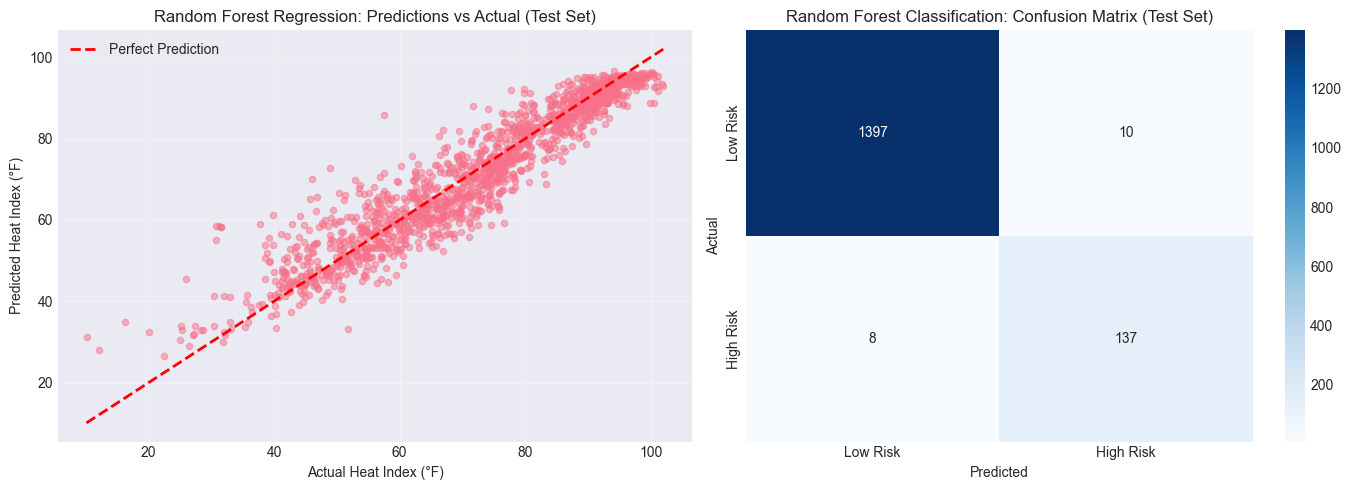

✓ Evaluation plots saved


In [14]:
# COMPREHENSIVE MODEL EVALUATION
# Evaluate both regression and classification models with metrics and visualizations

print("=" * 80)
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 80)

# Refresh predictions for both models
y_train_pred_reg = rf_regressor.predict(X_train)
y_val_pred_reg = rf_regressor.predict(X_val)
y_test_pred_reg = rf_regressor.predict(X_test)

y_train_pred_cls = rf_classifier.predict(X_train)
y_val_pred_cls = rf_classifier.predict(X_val)
y_test_pred_cls = rf_classifier.predict(X_test)

# Regression evaluation
print("\n" + "=" * 80)
print("REGRESSION PERFORMANCE (Forecasting Apparent Temperature)")
print("=" * 80)

# Calculate regression metrics
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_reg))
val_rmse = np.sqrt(mean_squared_error(y_val_reg, y_val_pred_reg))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_reg))
train_mae = mean_absolute_error(y_train_reg, y_train_pred_reg)
val_mae = mean_absolute_error(y_val_reg, y_val_pred_reg)
test_mae = mean_absolute_error(y_test_reg, y_test_pred_reg)
train_r2 = r2_score(y_train_reg, y_train_pred_reg)
val_r2 = r2_score(y_val_reg, y_val_pred_reg)
test_r2 = r2_score(y_test_reg, y_test_pred_reg)

# Print regression results
print(f"Train - RMSE: {train_rmse:.2f}°F, MAE: {train_mae:.2f}°F, R²: {train_r2:.4f}")
print(f"Val   - RMSE: {val_rmse:.2f}°F, MAE: {val_mae:.2f}°F, R²: {val_r2:.4f}")
print(f"Test  - RMSE: {test_rmse:.2f}°F, MAE: {test_mae:.2f}°F, R²: {test_r2:.4f}")

# Classification evaluation
print("\n" + "=" * 80)
print("CLASSIFICATION PERFORMANCE (Predicting Heat Risk)")
print("=" * 80)

# Calculate classification metrics
train_acc = accuracy_score(y_train_cls, y_train_pred_cls)
val_acc = accuracy_score(y_val_cls, y_val_pred_cls)
test_acc = accuracy_score(y_test_cls, y_test_pred_cls)
train_precision = precision_score(y_train_cls, y_train_pred_cls, zero_division=0)
val_precision = precision_score(y_val_cls, y_val_pred_cls, zero_division=0)
test_precision = precision_score(y_test_cls, y_test_pred_cls, zero_division=0)
train_recall = recall_score(y_train_cls, y_train_pred_cls, zero_division=0)
val_recall = recall_score(y_val_cls, y_val_pred_cls, zero_division=0)
test_recall = recall_score(y_test_cls, y_test_pred_cls, zero_division=0)
train_f1 = f1_score(y_train_cls, y_train_pred_cls, zero_division=0)
val_f1 = f1_score(y_val_cls, y_val_pred_cls, zero_division=0)
test_f1 = f1_score(y_test_cls, y_test_pred_cls, zero_division=0)

# Print classification results
print(f"Train - Accuracy: {train_acc:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
print(f"Val   - Accuracy: {val_acc:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
print(f"Test  - Accuracy: {test_acc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1: {test_f1:.4f}")

# Create visualizations
print("\n" + "=" * 80)
print("VISUALIZATIONS")
print("=" * 80)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression predictions vs actual
axes[0].scatter(y_test_reg, y_test_pred_reg, alpha=0.5, s=20)
# Add diagonal line (y=x)
min_val = min(y_test_reg.min(), y_test_pred_reg.min())
max_val = max(y_test_reg.max(), y_test_pred_reg.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Heat Index (°F)')
axes[0].set_ylabel('Predicted Heat Index (°F)')
axes[0].set_title('Random Forest Regression: Predictions vs Actual (Test Set)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Classification confusion matrix
cm = confusion_matrix(y_test_cls, y_test_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['Low Risk', 'High Risk'], 
            yticklabels=['Low Risk', 'High Risk'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Random Forest Classification: Confusion Matrix (Test Set)')

# Save visualization
plt.tight_layout()
os.makedirs('models/random_forest', exist_ok=True)
plt.savefig('models/random_forest/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Evaluation plots saved")


## Step 10: Feature Importance Analysis

Analyze and visualize feature importance from both models. Extract feature importance and create visualizations comparing which features matter for temperature forecasting vs risk prediction.


FEATURE IMPORTANCE ANALYSIS

Top 10 Features - Regression (Temperature Forecasting):
             feature  importance
20      TempPressure    0.191562
5          HeatIndex    0.156264
2           TempAvgF    0.127219
17  TempAvgF_squared    0.104745
1           TempLowF    0.079386
13      TempAvg_7day    0.073512
0          TempHighF    0.061710
15       PrevDayTemp    0.052387
4       DewPointAvgF    0.045383
21    Season_encoded    0.026149

Top 10 Features - Classification (Heat Risk Prediction):
                       feature  importance
0                    TempHighF    0.330285
20                TempPressure    0.139769
2                     TempAvgF    0.130356
17            TempAvgF_squared    0.085542
15                 PrevDayTemp    0.080491
13                TempAvg_7day    0.050784
5                    HeatIndex    0.033433
12              DailyTempRange    0.031405
18  HumidityAvgPercent_squared    0.017338
4                 DewPointAvgF    0.016223


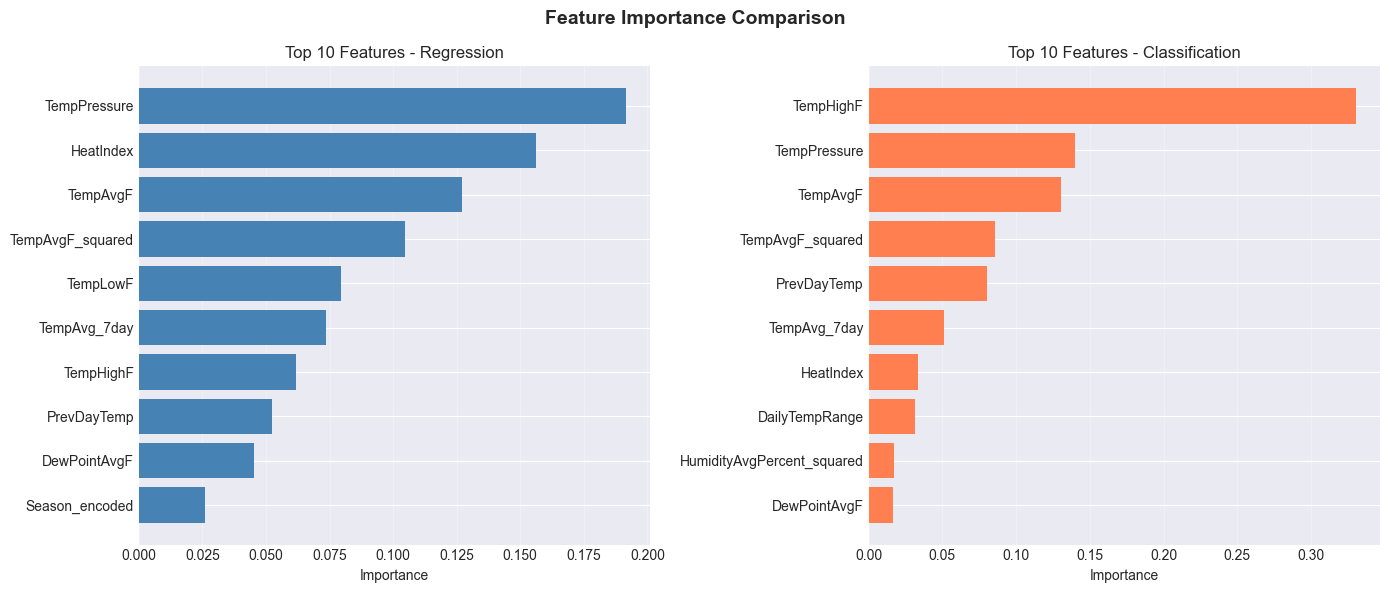


✓ Feature importance plots saved


In [15]:
# FEATURE IMPORTANCE ANALYSIS
# Extract feature importance from both models and visualize
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Extract feature importance from Random Forest regressor
feature_importance_reg = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_regressor.feature_importances_
}).sort_values('importance', ascending=False)

# Extract feature importance from Random Forest classifier
feature_importance_cls = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

# Print top features for each model
print("\nTop 10 Features - Regression (Temperature Forecasting):")
print(feature_importance_reg.head(10))
print("\nTop 10 Features - Classification (Heat Risk Prediction):")
print(feature_importance_cls.head(10))

# Visualize feature importance
# Create subplots for both models using horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')

top_n = 10  # Number of top features to display

# Plot regression feature importance
top_features_reg = feature_importance_reg.head(top_n)
axes[0].barh(range(len(top_features_reg)), top_features_reg['importance'], color='steelblue')
axes[0].set_yticks(range(len(top_features_reg)))
axes[0].set_yticklabels(top_features_reg['feature'])
axes[0].set_xlabel('Importance')
axes[0].set_title(f'Top {top_n} Features - Regression')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Plot classification feature importance
top_features_cls = feature_importance_cls.head(top_n)
axes[1].barh(range(len(top_features_cls)), top_features_cls['importance'], color='coral')
axes[1].set_yticks(range(len(top_features_cls)))
axes[1].set_yticklabels(top_features_cls['feature'])
axes[1].set_xlabel('Importance')
axes[1].set_title(f'Top {top_n} Features - Classification')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

# Save visualization
plt.tight_layout()
os.makedirs('models/random_forest', exist_ok=True)
plt.savefig('models/random_forest/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Feature importance plots saved")


## Step 11: Save Models and Predictions

Save trained models and create prediction files. Save both regression and classification models, create prediction DataFrames with dates and predictions.


In [16]:
# SAVE MODELS AND PREDICTIONS
# Save all trained models and create prediction DataFrames
print("=" * 80)
print("SAVING MODELS AND PREDICTIONS")
print("=" * 80)

# Create output directory
os.makedirs('models/random_forest', exist_ok=True)

# Save all models using joblib
joblib.dump(rf_regressor, 'models/random_forest/rf_regression.pkl')
joblib.dump(rf_classifier, 'models/random_forest/rf_classification.pkl')
print("✓ Models saved")

# Get prediction probabilities for classification models
y_val_pred_cls_proba = rf_classifier.predict_proba(X_val)[:, 1]  # Probability of class 1
y_test_pred_cls_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Extract dates from validation and test data
# Use the regression mask (same mask used for both regression and classification after filtering)
val_dates = val_data.loc[val_mask, 'Date'].values
test_dates = test_data.loc[test_mask, 'Date'].values

# Sanity checks
assert len(val_dates) == len(y_val_pred_reg), f"Val regression dates length mismatch: {len(val_dates)} vs {len(y_val_pred_reg)}"
assert len(val_dates) == len(y_val_pred_cls), f"Val classification dates length mismatch: {len(val_dates)} vs {len(y_val_pred_cls)}"
assert len(test_dates) == len(y_test_pred_reg), f"Test regression dates length mismatch: {len(test_dates)} vs {len(y_test_pred_reg)}"
assert len(test_dates) == len(y_test_pred_cls), f"Test classification dates length mismatch: {len(test_dates)} vs {len(y_test_pred_cls)}"
print("✓ Date alignment verified")

# Create prediction DataFrames
predictions_val = pd.DataFrame({
    'Date': val_dates,
    'actual_heat_index': y_val_reg.values,
    'predicted_heat_index': y_val_pred_reg,
    'actual_heat_risk': y_val_cls.values,
    'predicted_heat_risk': y_val_pred_cls,
    'predicted_heat_risk_proba': y_val_pred_cls_proba
})

predictions_test = pd.DataFrame({
    'Date': test_dates,
    'actual_heat_index': y_test_reg.values,
    'predicted_heat_index': y_test_pred_reg,
    'actual_heat_risk': y_test_cls.values,
    'predicted_heat_risk': y_test_pred_cls,
    'predicted_heat_risk_proba': y_test_pred_cls_proba
})

# Save predictions to CSV files
predictions_val.to_csv('models/random_forest/predictions_val.csv', index=False)
predictions_test.to_csv('models/random_forest/predictions_test.csv', index=False)
print("✓ Predictions saved")

# Verify that all files were saved
print("\nVerifying saved files:")
for file in ['rf_regression.pkl', 'rf_classification.pkl', 
             'predictions_val.csv', 'predictions_test.csv']:
    path = f'models/random_forest/{file}'
    if os.path.exists(path):
        file_size = os.path.getsize(path) / 1024  # Size in KB
        print(f"  ✓ {file} exists ({file_size:.2f} KB)")
    else:
        print(f"  ✗ {file} not found!")

print("\n" + "=" * 80)
print("✓ All models and predictions saved successfully!")
print("=" * 80)


SAVING MODELS AND PREDICTIONS
✓ Models saved
✓ Date alignment verified
✓ Predictions saved

Verifying saved files:
  ✓ rf_regression.pkl exists (36681.94 KB)
  ✓ rf_classification.pkl exists (997.12 KB)
  ✓ predictions_val.csv exists (80.44 KB)
  ✓ predictions_test.csv exists (81.85 KB)

✓ All models and predictions saved successfully!


## Summary

After completing all TODO sections, you should have:
- ✅ Features prepared and encoded
- ✅ Random Forest regressor trained and tuned
- ✅ Random Forest classifier trained and tuned
- ✅ Models evaluated with comprehensive metrics
- ✅ Feature importance analyzed and visualized
- ✅ Models saved to `models/random_forest/`
- ✅ Predictions saved to CSV files

**Next Steps**: 
- Review `models/random_forest/README.md` for submission requirements
- Ensure all deliverables are complete
- Proceed to `ensemble.ipynb` after all models complete their models
